
# 10. 진짜 한국어 글 (KLUE-MRC): 사다리 5단계

**문제**: 실제 뉴스와 위키 지문을 읽고 질문에 답한다. 지문에 답이 없으면 "모름"이라고 해야 한다(시험 2,000문제 중 641개, 32%).
점수는 맞으면 +1, 틀리면 −1, 답이 있는데 모름이면 0, 답이 없는데 모름이면 +1이다.

| 시스템 | 구성 |
|---|---|
| 범용 언어모델 단독 | LFM2.5-1.2B (12억), "답이 없으면 모름이라고 해" 지시 |
| 1차 MK1 | 범용 언어모델 후보 + NLI 확인 + 작은 판단 |
| **읽기 전문가** | mdeberta-v3-base (2.8억)를 KLUE-MRC 1.4만 문제로 학습. 자기 "답 없음" 점수로 거름 |
| MK1 v2 | 읽기 전문가 + NLI 확인 + 작은 판단 |


In [1]:

import json
import numpy as np
import matplotlib.pyplot as plt
from cognitive_lab import summary as S
from cognitive_lab import viz as V
V.setup()
SEEDS = (42, 43, 44)
runs = {s: json.loads((S.RESULTS / f"world-v5_mk1-reader_seed-{s}.json").read_text(encoding="utf-8")) for s in SEEDS}
r = runs[42]
mk1v2 = [runs[s]["mk1_v2"]["score"] for s in SEEDS]
print("MK1 v2 seeds:", mk1v2, " 읽기 전문가 단독:", r["reader_alone"]["score"])
print("MK1 v2 - 읽기 전문가:", [runs[s]["mk1_minus_reader_alone"] for s in SEEDS])


MK1 v2 seeds: [0.4755, 0.4635, 0.4685]  읽기 전문가 단독: 0.471
MK1 v2 - 읽기 전문가: [{'mean': 0.0045, 'bootstrap_95': [-0.016, 0.0255]}, {'mean': -0.0075, 'bootstrap_95': [-0.0285, 0.014]}, {'mean': -0.0025, 'bootstrap_95': [-0.023, 0.017]}]



## 1. 읽는 실력: 전문가가 범용 모델을 크게 이긴다

답이 있는 질문에서 후보가 맞는 비율이다. 범용 언어모델의 두 값은 검증 세트 진단에서 나왔다(지문 전체 / 정답 문장만 줬을 때).


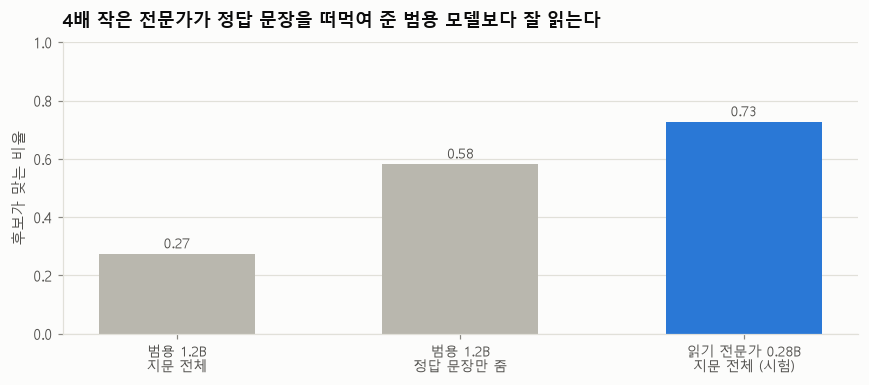

In [2]:

bars = [("범용 1.2B\n지문 전체", 0.273, V.NEUTRAL), ("범용 1.2B\n정답 문장만 줌", 0.581, V.NEUTRAL),
        ("읽기 전문가 0.28B\n지문 전체 (시험)", 0.726, V.BLUE)]
fig, ax = plt.subplots(figsize=(8, 3.6))
for i, (label, v, c) in enumerate(bars):
    ax.bar(i, v, width=0.55, color=c)
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=9, color=V.TEXT_SECONDARY)
ax.set_xticks(range(3), [b[0] for b in bars], fontsize=9)
ax.set_ylim(0, 1)
ax.grid(axis="x", visible=False)
ax.set_ylabel("후보가 맞는 비율")
ax.set_title("4배 작은 전문가가 정답 문장을 떠먹여 준 범용 모델보다 잘 읽는다", pad=10)
fig.tight_layout()
plt.show()



## 2. 최종 점수


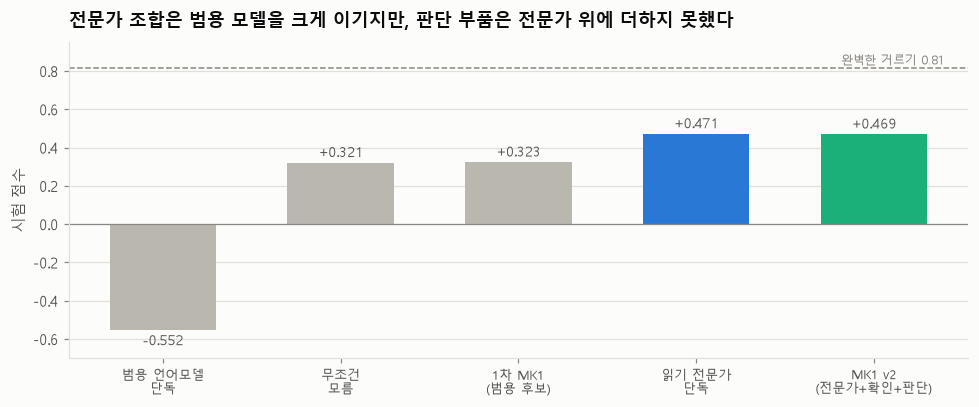

In [3]:

items = [("범용 언어모델\n단독", r["lm_alone"]["score"], V.NEUTRAL), ("무조건\n모름", r["always_unknown"]["score"], V.NEUTRAL),
         ("1차 MK1\n(범용 후보)", np.mean([runs[s]["mk1_v1"] for s in SEEDS]), V.NEUTRAL),
         ("읽기 전문가\n단독", r["reader_alone"]["score"], V.BLUE), ("MK1 v2\n(전문가+확인+판단)", np.mean(mk1v2), V.AQUA)]
fig, ax = plt.subplots(figsize=(9, 3.8))
for i, (label, v, c) in enumerate(items):
    ax.bar(i, v, width=0.6, color=c)
    ax.text(i, v + (0.03 if v >= 0 else -0.08), f"{v:+.3f}", ha="center", fontsize=9, color=V.TEXT_SECONDARY)
ax.axhline(0, color=V.MUTED, lw=0.8)
ax.axhline(r["oracle_filter"], color=V.MUTED, ls="--", lw=1)
ax.text(4.4, r["oracle_filter"] + 0.02, f"완벽한 거르기 {r['oracle_filter']:.2f}", ha="right", fontsize=8, color=V.MUTED)
ax.set_xticks(range(len(items)), [x[0] for x in items], fontsize=8.5)
ax.set_ylim(-0.7, 0.95)
ax.grid(axis="x", visible=False)
ax.set_ylabel("시험 점수")
ax.set_title("전문가 조합은 범용 모델을 크게 이기지만, 판단 부품은 전문가 위에 더하지 못했다", pad=10)
fig.tight_layout()
plt.show()



## 3. 정리

- **전문가 > 범용**: 읽기 전문가(2.8억)를 쓴 시스템이 범용 언어모델(12억) 단독보다 **+1.02** 높다. 범용 모델은 98% 답하면서 답이 없는 질문에서도 지어낸다. 전문가는 35%만 답하고, 답할 때 76%를 맞힌다.
- **판단 부품의 기여는 없었다**: MK1 v2 − 읽기 전문가 단독 = +0.005 / −0.008 / −0.003으로, 구간이 0을 포함한다. 잘 학습된 전문가는 이미 자기 확신(답 없음 점수)을 갖고 있다.
- **교훈**: 한 가지 능력 안에서는 잘 학습된 전문가 하나로 충분하다. 조합과 연결의 가치는 1–4단계처럼 **여러 능력을 합쳐야 하는 문제**에서 나온다.
- 과정에서 잡은 버그 2개: 글자 F1 채점("2013년"을 "2014년"의 정답으로 침), 토크나이저 overflow(긴 지문 뒷부분을 버림, 학습 전에 발견).
